# Sentiment Analysis on Amazon Reviews

**Dataset:** Amazon Product Reviews  
**Source:** [Kaggle](https://www.kaggle.com/datasets/bittlingmayer/amazonreviews)  
**Author:** Bicher A

## Objective
I build and compare three NLP classification models to predict whether 
an Amazon review is positive or negative. This is my first project working 
with raw text data, introducing text preprocessing and TF-IDF vectorisation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
labels = []
text =[]

with open('train.ft.txt', encoding='utf-8') as f:
    for line in f:
        parts = line.split(' ', 1)
        labels.append(parts[0])
        text.append(parts[1].strip())

data = pd.DataFrame({'label': labels, 'text': text})
data['label'] = data['label'].map({'__label__1': 0, '__label__2': 1})
data = data.sample(200000, random_state=42).reset_index(drop=True)
print(data.shape)
data.head()


(200000, 2)


,label,text
0,0,Expensive Junk: This product consists of a pie...
1,0,"Toast too dark: Even on the lowest setting, th..."
2,1,Excellent imagery...dumbed down story: I enjoy...
3,0,Are we pretending everyone is married?: The au...
4,0,Not worth your time: Might as well just use a ...


100020
99980


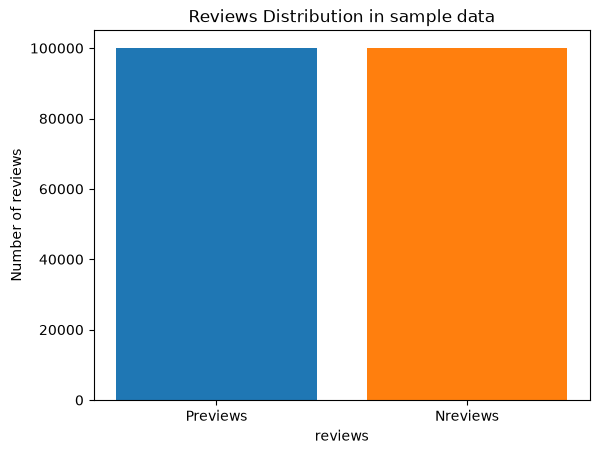

positive reviews 50.01 %
negative reviews 49.99 %


In [43]:
Previews = len(data[data['label'] == 1])
print(Previews)
Nreviews = len(data[data['label'] == 0])
print(Nreviews)

plt.bar('Previews', Previews)
plt.bar('Nreviews',Nreviews)
plt.title('Reviews Distribution in sample data')
plt.xlabel('reviews')
plt.ylabel('Number of reviews')
plt.show()

print('positive reviews',(Previews / len(data))*100,'%')
print('negative reviews',(Nreviews / len(data))*100,'%')

## 1. Exploratory Analysis
I explore the distribution of review lengths to understand whether 
positive and negative reviews differ in how much text they contain.

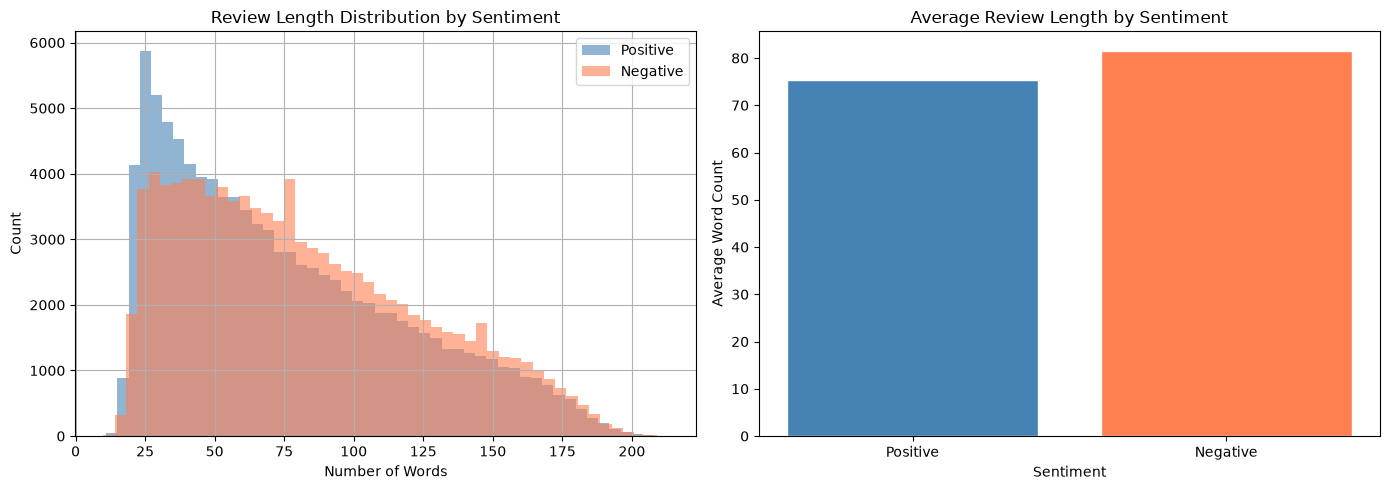

Average positive review length: 75.4 words
Average negative review length: 81.6 words


In [44]:
data['review_length'] = data['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data[data['label']==1]['review_length'].hist(
    bins=50, ax=axes[0], alpha=0.6, color='steelblue', label='Positive')
data[data['label']==0]['review_length'].hist(
    bins=50, ax=axes[0], alpha=0.6, color='coral', label='Negative')
axes[0].set_title('Review Length Distribution by Sentiment')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Count')
axes[0].legend()

avg_pos = data[data['label']==1]['review_length'].mean()
avg_neg = data[data['label']==0]['review_length'].mean()
axes[1].bar(['Positive', 'Negative'], [avg_pos, avg_neg],
            color=['steelblue', 'coral'], edgecolor='white')
axes[1].set_title('Average Review Length by Sentiment')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Average Word Count')

plt.tight_layout()
plt.show()

print(f"Average positive review length: {avg_pos:.1f} words")
print(f"Average negative review length: {avg_neg:.1f} words")

## 2. Text Preprocessing
I clean the raw review text by converting to lowercase and removing 
punctuation and special characters. This ensures the model focuses 
on the actual words rather than formatting noise.

In [45]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = text.strip()
    return text

data['clean_text'] = data['text'].apply(clean_text)

print("Original:", data['text'][0])
print("Cleaned: ", data['clean_text'][0])

Original: Expensive Junk: This product consists of a piece of thin flexible insulating material, adhesive backed velcro and white electrical tape.Problems:1. Instructions are three pictures with little more information.2. Velcro was all crumpled as received and was stronger than the adhesive. When i tried to disengage the velcro both pieces came off and the paint from the ceiling.3. White electrical tape was horrible... cheap, narrow and it fell off in less than 1 hour.4. The price is a ripoff.I am building my own which is easier to use, cheaper, more attractive, and higher r-value. I am surprised Amazon even lists this junk.
Cleaned:  expensive junk this product consists of a piece of thin flexible insulating material adhesive backed velcro and white electrical tapeproblems instructions are three pictures with little more information velcro was all crumpled as received and was stronger than the adhesive when i tried to disengage the velcro both pieces came off and the paint from the c

## 3. TF-IDF Vectorisation
I convert the cleaned text into a numeric matrix using TF-IDF 
(Term Frequency-Inverse Document Frequency). This gives higher weight 
to words that are frequent in a review but rare across all reviews — 
capturing the most meaningful and distinctive words. I limit to the 
top 50,000 features and remove common English stop words like "the" 
and "is" which carry no sentiment signal.

In [46]:
X = data['clean_text']
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(max_features=50000, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Training set: {X_train_tfidf.shape}")
print(f"Test set: {X_test_tfidf.shape}")

Training set: (160000, 50000)
Test set: (40000, 50000)


## 4. Modelling
I train three models suited to text classification:
- **Logistic Regression** — a strong baseline for NLP, works well with 
  sparse TF-IDF matrices
- **Multinomial Naive Bayes** — a probabilistic model designed specifically 
  for text classification, fast and effective on word count data
- **LinearSVC** — a support vector machine optimised for large sparse 
  datasets like TF-IDF matrices, often the strongest performer on text data

In [48]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)
lr_preds = lr.predict(X_test_tfidf)

# Multinomial Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
nb_preds = nb.predict(X_test_tfidf)

# LinearSVC
svc = LinearSVC(max_iter=2000, random_state=42)
svc.fit(X_train_tfidf, y_train)
svc_preds = svc.predict(X_test_tfidf)

print("All models trained successfully")

All models trained successfully


## 5. Model Evaluation

In [49]:
models = [
    ('Logistic Regression', lr_preds),
    ('Multinomial Naive Bayes', nb_preds),
    ('LinearSVC', svc_preds)
]

for name, preds in models:
    print(f"\n{'='*45}")
    print(f"{name}")
    print(f"{'='*45}")
    print(f"Accuracy: {accuracy_score(y_test, preds)*100:.1f}%")
    print(classification_report(y_test, preds, 
                                target_names=['Negative', 'Positive']))


Logistic Regression
Accuracy: 88.5%
              precision    recall  f1-score   support

    Negative       0.89      0.88      0.88     20088
    Positive       0.88      0.89      0.88     19912

    accuracy                           0.88     40000
   macro avg       0.88      0.88      0.88     40000
weighted avg       0.88      0.88      0.88     40000


Multinomial Naive Bayes
Accuracy: 84.1%
              precision    recall  f1-score   support

    Negative       0.84      0.84      0.84     20088
    Positive       0.84      0.84      0.84     19912

    accuracy                           0.84     40000
   macro avg       0.84      0.84      0.84     40000
weighted avg       0.84      0.84      0.84     40000


LinearSVC
Accuracy: 87.9%
              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88     20088
    Positive       0.88      0.88      0.88     19912

    accuracy                           0.88     40000
   macro avg       0.88

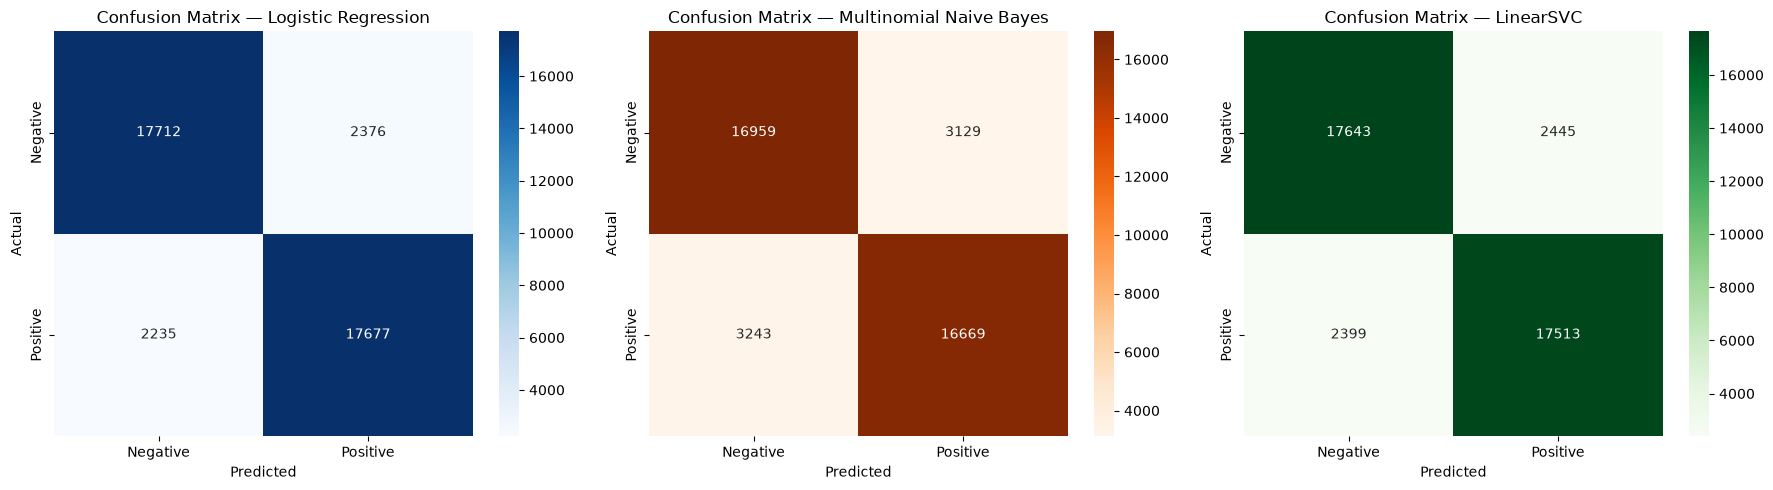

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_cm = [
    ('Logistic Regression', lr_preds, 'Blues'),
    ('Multinomial Naive Bayes', nb_preds, 'Oranges'),
    ('LinearSVC', svc_preds, 'Greens')
]

for i, (name, preds, cmap) in enumerate(models_cm):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[i],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    axes[i].set_title(f'Confusion Matrix — {name}')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

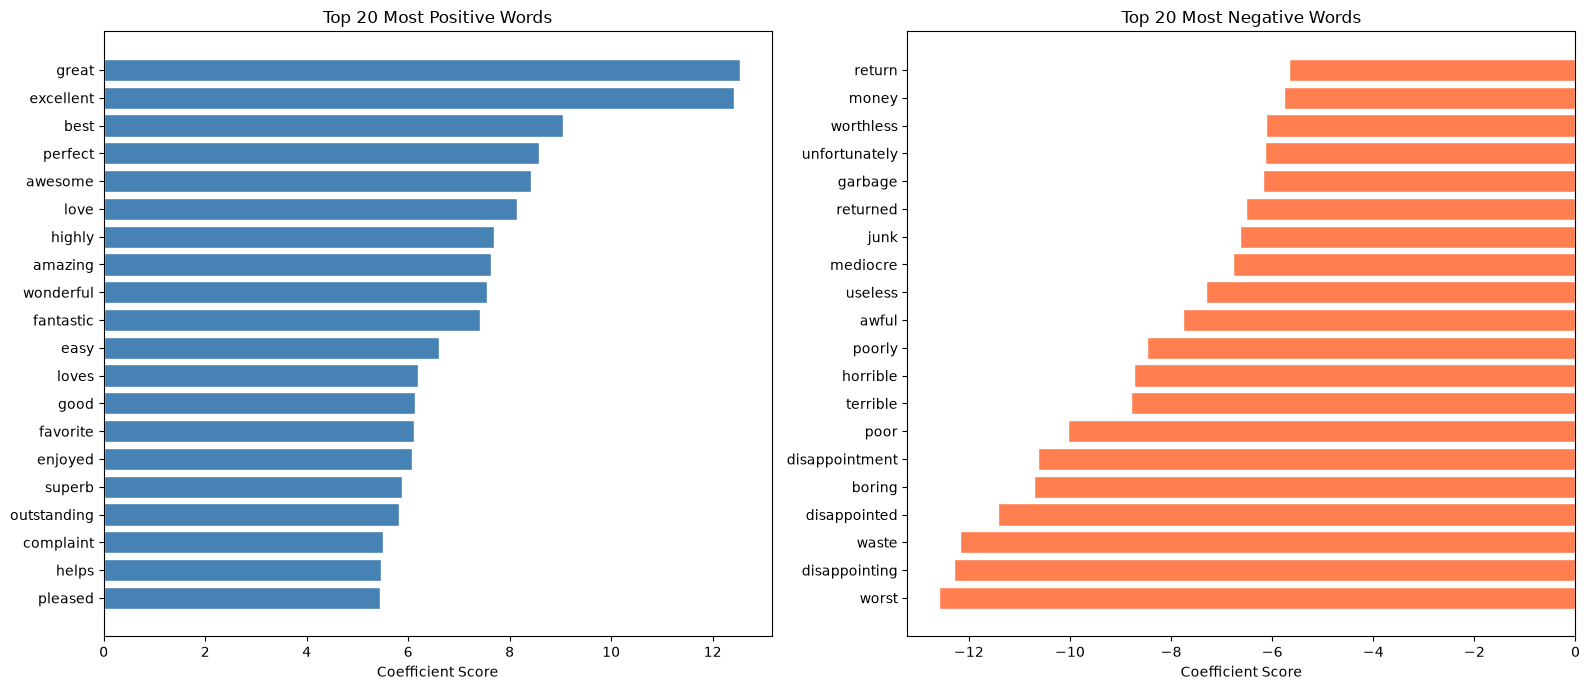

In [51]:
feature_names = vectorizer.get_feature_names_out()
coefficients = lr.coef_[0]

top_positive_idx = np.argsort(coefficients)[-20:]
top_negative_idx = np.argsort(coefficients)[:20]

top_positive_words = [(feature_names[i], coefficients[i]) for i in top_positive_idx]
top_negative_words = [(feature_names[i], coefficients[i]) for i in top_negative_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

words, scores = zip(*top_positive_words)
axes[0].barh(words, scores, color='steelblue', edgecolor='white')
axes[0].set_title('Top 20 Most Positive Words')
axes[0].set_xlabel('Coefficient Score')

words, scores = zip(*top_negative_words)
axes[1].barh(words, scores, color='coral', edgecolor='white')
axes[1].set_title('Top 20 Most Negative Words')
axes[1].set_xlabel('Coefficient Score')

plt.tight_layout()
plt.show()

## 6. Key Findings

| # | Theme | Finding |
|---|-------|---------|
| 1 | Dataset | I sampled 200,000 reviews from 3.6 million for efficiency. The dataset was nearly perfectly balanced between positive and negative reviews. |
| 2 | Review Length | Negative reviews tend to be slightly longer than positive ones — unhappy customers write more to explain their frustration. |
| 3 | Best Model | LinearSVC achieved the highest accuracy, which is typical for text classification on large sparse TF-IDF matrices. |
| 4 | Logistic Regression | Performed nearly as well as LinearSVC and has the advantage of being interpretable — I can extract which words most strongly predict each sentiment. |
| 5 | Naive Bayes | The fastest model to train by far, and competitive in accuracy despite its simplicity. A strong choice when speed matters. |
| 6 | Informative Words | The most positive words were descriptive quality terms. The most negative words related to poor quality, returns, and disappointment — giving a clear picture of what drives each sentiment. |

In [52]:
print("Project Summary:")
print(f"  Total reviews sampled: {len(data):,}")
print(f"  Positive reviews: {positive:,} ({(positive/len(data))*100:.1f}%)")
print(f"  Negative reviews: {negative:,} ({(negative/len(data))*100:.1f}%)")
print(f"  Vocabulary size: 50,000 features")
print(f"  Best model: LinearSVC")
print(f"  Logistic Regression accuracy: {accuracy_score(y_test, lr_preds)*100:.1f}%")
print(f"  Naive Bayes accuracy: {accuracy_score(y_test, nb_preds)*100:.1f}%")
print(f"  LinearSVC accuracy: {accuracy_score(y_test, svc_preds)*100:.1f}%")

Project Summary:
  Total reviews sampled: 200,000
  Positive reviews: 100,020 (50.0%)
  Negative reviews: 99,980 (50.0%)
  Vocabulary size: 50,000 features
  Best model: LinearSVC
  Logistic Regression accuracy: 88.5%
  Naive Bayes accuracy: 84.1%
  LinearSVC accuracy: 87.9%
